# Paramount Seating Two/Four top 

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2023, University of Chicago 

---

The Paramount Restaurant is a Boston institution.  Dine-in customers are known to line up for an hour on busy weekends for brunch.   They are investigating the use of Take-Out/Delivery orders. Take-Out orders jump to the front of the line for the cooks, and do not require seating.  Management is worried about the impact Take-out will have on their regular Dine-in customers.

In this initial Paramount Simulation we assume the following.  

- The unit of time is 1 second
- TAKE_OUT_PERCENT is the average proportion of customers that order TAKE_OUT 
- Dine-in Customers arrive according to an exponential distribution with mean `MEAN_TIME_BETWEEN_ARRIVALS` time units between them
- Dine-in customers then queue for one of `NUM_COOKS`
- Take-out orders also queue for a cook, but jump to the front of the line.
- It takes one cook an exponentially distributed time with mean `MEAN_COOK_TIME_DURATION` time untis to prepare one the food order of one Dine-in customer or Take-out customer
- Dine-In customeers then queue for one of `NUM_SEATS`
- The time it takes one Dine-in customer to eat and vacate a seat follows a Uniform(`LOW_EATING_DURATION`,`HIGH_EATING_DURATION`) distribted floating point time units. 
- Run the simulation for `SIM_LENGTH` time units 

Simplifying assumtion:

- We assume communal seating, that is, each customer sits at communal tables with no regard to party/table size. 

Hint:

- To enable Take-Out customers to jump to the head of the line for a Cook, use the `priority` attribute setting for each Entity

### Part 3: Seating

We now consider that customers arrive in a party of size Two or Four.  Assume that a single cook will prepare the food for the entire party.  After the food is prepared the party will then queue accordingly for a Two-Top or Four-Top table.  `PARTY_SIZE_TWO_PERCENTAGE` of the parties are of size Two, and the remaining are of size Four.

There are `NUM_TWO_TOPS` and `NUM_FOUR_TOPS` of each table type.

- Add a threshold policy to your notebook that will seat a 2-party at a Four-Top if at least some threshold value of Four-Tops is empty.
- Plot the Four-Top Empty Threshold value (0..7) vs. the Average Wait Time per PERSON  
- Compute the table utlizations for Two Tops, and Four Tops


In [1]:
import numpy as np
import simpy
from simpy_helpers import Entity, Resource, Source, Stats

In [2]:
# New Params for 2/4 top seating
SIM_LENGTH = 488000 # 8 hours 
TAKE_OUT_PERCENTAGE = 0.30
MEAN_TIME_BETWEEN_ARRIVALS = 150
NUM_COOKS = 4
MEAN_COOK_TIME_DURATION = 140 
LOW_EATING_DURATION = 1000
HIGH_EATING_DURATION = 2000
#
#  New Seating Parms
#
NUM_TWO_TOPS = 5 
NUM_FOUR_TOPS = 7 
PARTY_SIZE_TWO_PERCENTAGE = 0.35    # The rest are of size Four 
NUM_FOUR_TOP_EMPTY_THRESHOLD = 2 

**1. Define your Source class**

In [3]:
# Here is the Source subclass
class GenerateCustomers(Source):
    def interarrival_time(self):
        return np.random.exponential(MEAN_TIME_BETWEEN_ARRIVALS)
    
    def build_entity(self):
        attributes = {}
        customer_type = np.random.choice(["take_out", "dine_in"], p=[TAKE_OUT_PERCENTAGE,(1.0-TAKE_OUT_PERCENTAGE)])
        attributes["customer_type"] = customer_type
        
        if customer_type == "take_out":
            attributes["priority"] = 0 

        else:
            attributes["priority"] = 1

        party_size = np.random.choice([2, 4], p=[PARTY_SIZE_TWO_PERCENTAGE,(1.0-PARTY_SIZE_TWO_PERCENTAGE)])
        attributes["party_size"] = party_size
            
        return Customer(env, attributes) 

**2. Define your Entity class**

In [4]:
def two_top_party_should_queue_for_four_top():
    
    if two_top_seats.count < NUM_TWO_TOPS: # A two top is available
        return False
        
    num_empty_four_tops = NUM_FOUR_TOPS - four_top_seats.count

    if num_empty_four_tops > NUM_FOUR_TOP_EMPTY_THRESHOLD:
        return True

    return False

In [5]:
## Here is the Entity Subclass
class Customer(Entity):
    def process(self):
        yield self.wait_for_resource(cooks)
        yield self.process_at_resource(cooks)
        self.release_resource(cooks)
        
        if self.attributes["customer_type"]=="dine_in":
            if self.attributes["party_size"]==2 and not two_top_party_should_queue_for_four_top():
                yield self.wait_for_resource(two_top_seats)
                yield self.process_at_resource(two_top_seats)
                self.release_resource(two_top_seats)

            else:
                yield self.wait_for_resource(four_top_seats)
                yield self.process_at_resource(four_top_seats)
                self.release_resource(four_top_seats)

**3. Define your Resource classes**

In [6]:
# Here is the Resource subclass
class Cooks(Resource):
    def service_time(self, entity):
        return np.random.exponential(MEAN_COOK_TIME_DURATION, size=entity.attributes['party_size']).sum()

class TwoSeats(Resource):
    def service_time(self, entity):
        return np.random.uniform(LOW_EATING_DURATION, HIGH_EATING_DURATION, size=entity.attributes['party_size']).max()

class FourSeats(Resource):
    def service_time(self, entity):
        return np.random.uniform(LOW_EATING_DURATION, HIGH_EATING_DURATION, size=entity.attributes['party_size']).max()

**4. Run your Simulation.**

In [7]:
np.random.seed(429) 
env = simpy.Environment()

two_top_seats = TwoSeats(env, capacity=NUM_TWO_TOPS)
four_top_seats = FourSeats(env, capacity=NUM_FOUR_TOPS)
cooks = Cooks(env, capacity=NUM_COOKS)
source = GenerateCustomers(env)

env.process(source.start(debug=False))
env.run(until=SIM_LENGTH)

**5. Output the following statistics:**
- Average waiting time for Cooks
- Average waiting time for Two Tops 
- Average waiting time for Four Tops 
- Average eating time for Two Tops 
- Average eating time for Four Tops 


In [8]:
print(f'Average waiting time for Cooks is {round(np.mean(Stats.get_waiting_times(cooks)),2)} seconds')
print(f'Average waiting time for Seats for Dine-in party of 2 is {round(np.mean(Stats.get_waiting_times(two_top_seats)),2)} seconds')
print(f'Average waiting time for Seats for Dine-in party of 4 is {round(np.mean(Stats.get_waiting_times(four_top_seats)),2)} seconds')
print(f'Average eating time for Dine-in party of 2 is {round(np.mean(Stats.get_processing_times(two_top_seats)),2)} seconds')
print(f'Average eating time for Dine-in party of 4 is {round(np.mean(Stats.get_processing_times(four_top_seats)),2)} seconds')

Average waiting time for Cooks is 133.4 seconds
Average waiting time for Seats for Dine-in party of 2 is 83.32 seconds
Average waiting time for Seats for Dine-in party of 4 is 134.69 seconds
Average eating time for Dine-in party of 2 is 1670.68 seconds
Average eating time for Dine-in party of 4 is 1803.02 seconds


### Challenge:   Plot EMPTY Threshold vs. Average Wait Time per PERSON

NOTE: `[1,2,3] + [6,5,4]` yields a new list: `[1,2,3,6,5,4]`

NOTE:  In code below,  `average_wait_time = ??? ` needs to be completed

FOUR TOP EMPTY THRESHOLD: 0
   Avg Wait Time: 201.08148101998904
FOUR TOP EMPTY THRESHOLD: 1
   Avg Wait Time: 202.03539323471807
FOUR TOP EMPTY THRESHOLD: 2
   Avg Wait Time: 194.12972186586464
FOUR TOP EMPTY THRESHOLD: 3
   Avg Wait Time: 187.75768498250835
FOUR TOP EMPTY THRESHOLD: 4
   Avg Wait Time: 197.2969680124709
FOUR TOP EMPTY THRESHOLD: 7
   Avg Wait Time: 206.75572731977942


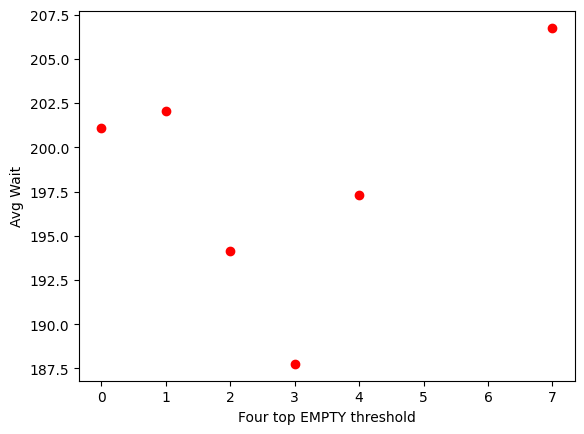

In [9]:
import matplotlib.pyplot as plt
SIM_LENGTH = 488000 # 8 hours 
TAKE_OUT_PERCENTAGE = 0.30
MEAN_TIME_BETWEEN_ARRIVALS = 150
NUM_COOKS = 4
MEAN_COOK_TIME_DURATION = 140 
LOW_EATING_DURATION = 1000
HIGH_EATING_DURATION = 2000
NUM_TWO_TOPS = 5 
NUM_FOUR_TOPS = 7 
PARTY_SIZE_TWO_PERCENTAGE = 0.35    # The rest are of size Four 

np.random.seed(189) 

num_four_top_empty_threshold_iterates = [0, 1, 2, 3, 4, NUM_FOUR_TOPS]
average_wait_times_for_table = []
num_runs = 50 

for NUM_FOUR_TOP_EMPTY_THRESHOLD in num_four_top_empty_threshold_iterates: 
    print(f"FOUR TOP EMPTY THRESHOLD: {NUM_FOUR_TOP_EMPTY_THRESHOLD}")
    each_run = []
    
    for i in range(num_runs):
        env = simpy.Environment()

        two_top_seats = TwoSeats(env, capacity=NUM_TWO_TOPS)
        four_top_seats = FourSeats(env, capacity=NUM_FOUR_TOPS)
        cooks = Cooks(env, capacity=NUM_COOKS)
        source = GenerateCustomers(env)

        env.process(source.start(debug=False))
        env.run(until=SIM_LENGTH)
        # compute wait time per person, not per party
        average_wait_time = np.mean(
            Stats.get_waiting_times(two_top_seats) * 2 + 
            Stats.get_waiting_times(four_top_seats, attributes={'party_size':2}) * 2 +
            Stats.get_waiting_times(four_top_seats, attributes={'party_size':4}) * 4
        )
        
        each_run.append(average_wait_time)
                
    print(f"   Avg Wait Time: {np.mean(each_run)}")
    average_wait_times_for_table.append(np.mean(each_run))
    
plt.plot(num_four_top_empty_threshold_iterates, average_wait_times_for_table,'ro')
plt.xlabel('Four top EMPTY threshold');
plt.ylabel('Avg Wait');
plt.show() 

### Challenge:  Computing table utilizations

#### Use the following parameters


In [11]:
# Lets repeat a more central threshold run
NUM_FOUR_TOP_EMPTY_THRESHOLD = 3
env = simpy.Environment()

two_top_seats = TwoSeats(env, capacity=NUM_TWO_TOPS)
four_top_seats = FourSeats(env, capacity=NUM_FOUR_TOPS)
cooks = Cooks(env, capacity=NUM_COOKS)
source = GenerateCustomers(env)

env.process(source.start(debug=False))
env.run(until=SIM_LENGTH)

### Table Utilization

One way to compute table utilization is to consider the total seat-hours occupied divided by total seat-hours available.

### CHALLENGE:  Compute 2 top utilization

### Challenge:  Compute 4 top utilization

